### Fantasy Draft Guide

In [10]:
import pandas as pd
import numpy as np

In [11]:
# Load in star players by position 
qbs = pd.read_csv('draft_proj_new_083023/QB/qb_star_criteria.csv')
rbs = pd.read_csv('draft_proj_new_083023/RB/rb_star_criteria.csv')
wrs = pd.read_csv('draft_proj_new_083023/WR/wr_star_criteria.csv')
tes = pd.read_csv('draft_proj_new_083023/TE/te_star_criteria.csv')
adp = pd.read_csv('data/fantasy_draft_adp/draft_adp_2023.csv')

In [12]:
player_cols = ['Player', 'Position']
qbs = qbs[player_cols]
rbs = rbs[player_cols]
wrs = wrs[player_cols]
tes = tes[player_cols]
adp = adp[['Name','Team','#']]

In [13]:
all_players = pd.concat([qbs,rbs])
all_players = pd.concat([all_players,wrs])
all_players = pd.concat([all_players,tes])

all_players_w_adp = all_players.merge(adp, left_on='Player', right_on='Name', how='inner')
all_players_w_adp = all_players_w_adp[['Player', 'Position', 'Team', '#']]
all_players_w_adp = all_players_w_adp.rename({'#': 'ADP_Ranking'}, axis=1)

In [14]:
all_players_w_adp_10team = all_players_w_adp
all_players_w_adp_12team = all_players_w_adp.copy(deep=True)

In [15]:
all_players_w_adp_10team['Round'] = np.ceil(all_players_w_adp['ADP_Ranking'] / 10)
all_players_w_adp_12team['Round'] = np.ceil(all_players_w_adp['ADP_Ranking'] / 12)

In [16]:
all_players_w_adp_10team = all_players_w_adp_10team.sort_values('ADP_Ranking')
all_players_w_adp_12team = all_players_w_adp_12team.sort_values('ADP_Ranking')

In [17]:
all_players_w_adp_10team.to_csv('fantasy_draft_guide/2023/draftguide_10team.csv')
all_players_w_adp_12team.to_csv('fantasy_draft_guide/2023/draftguide_12team.csv')

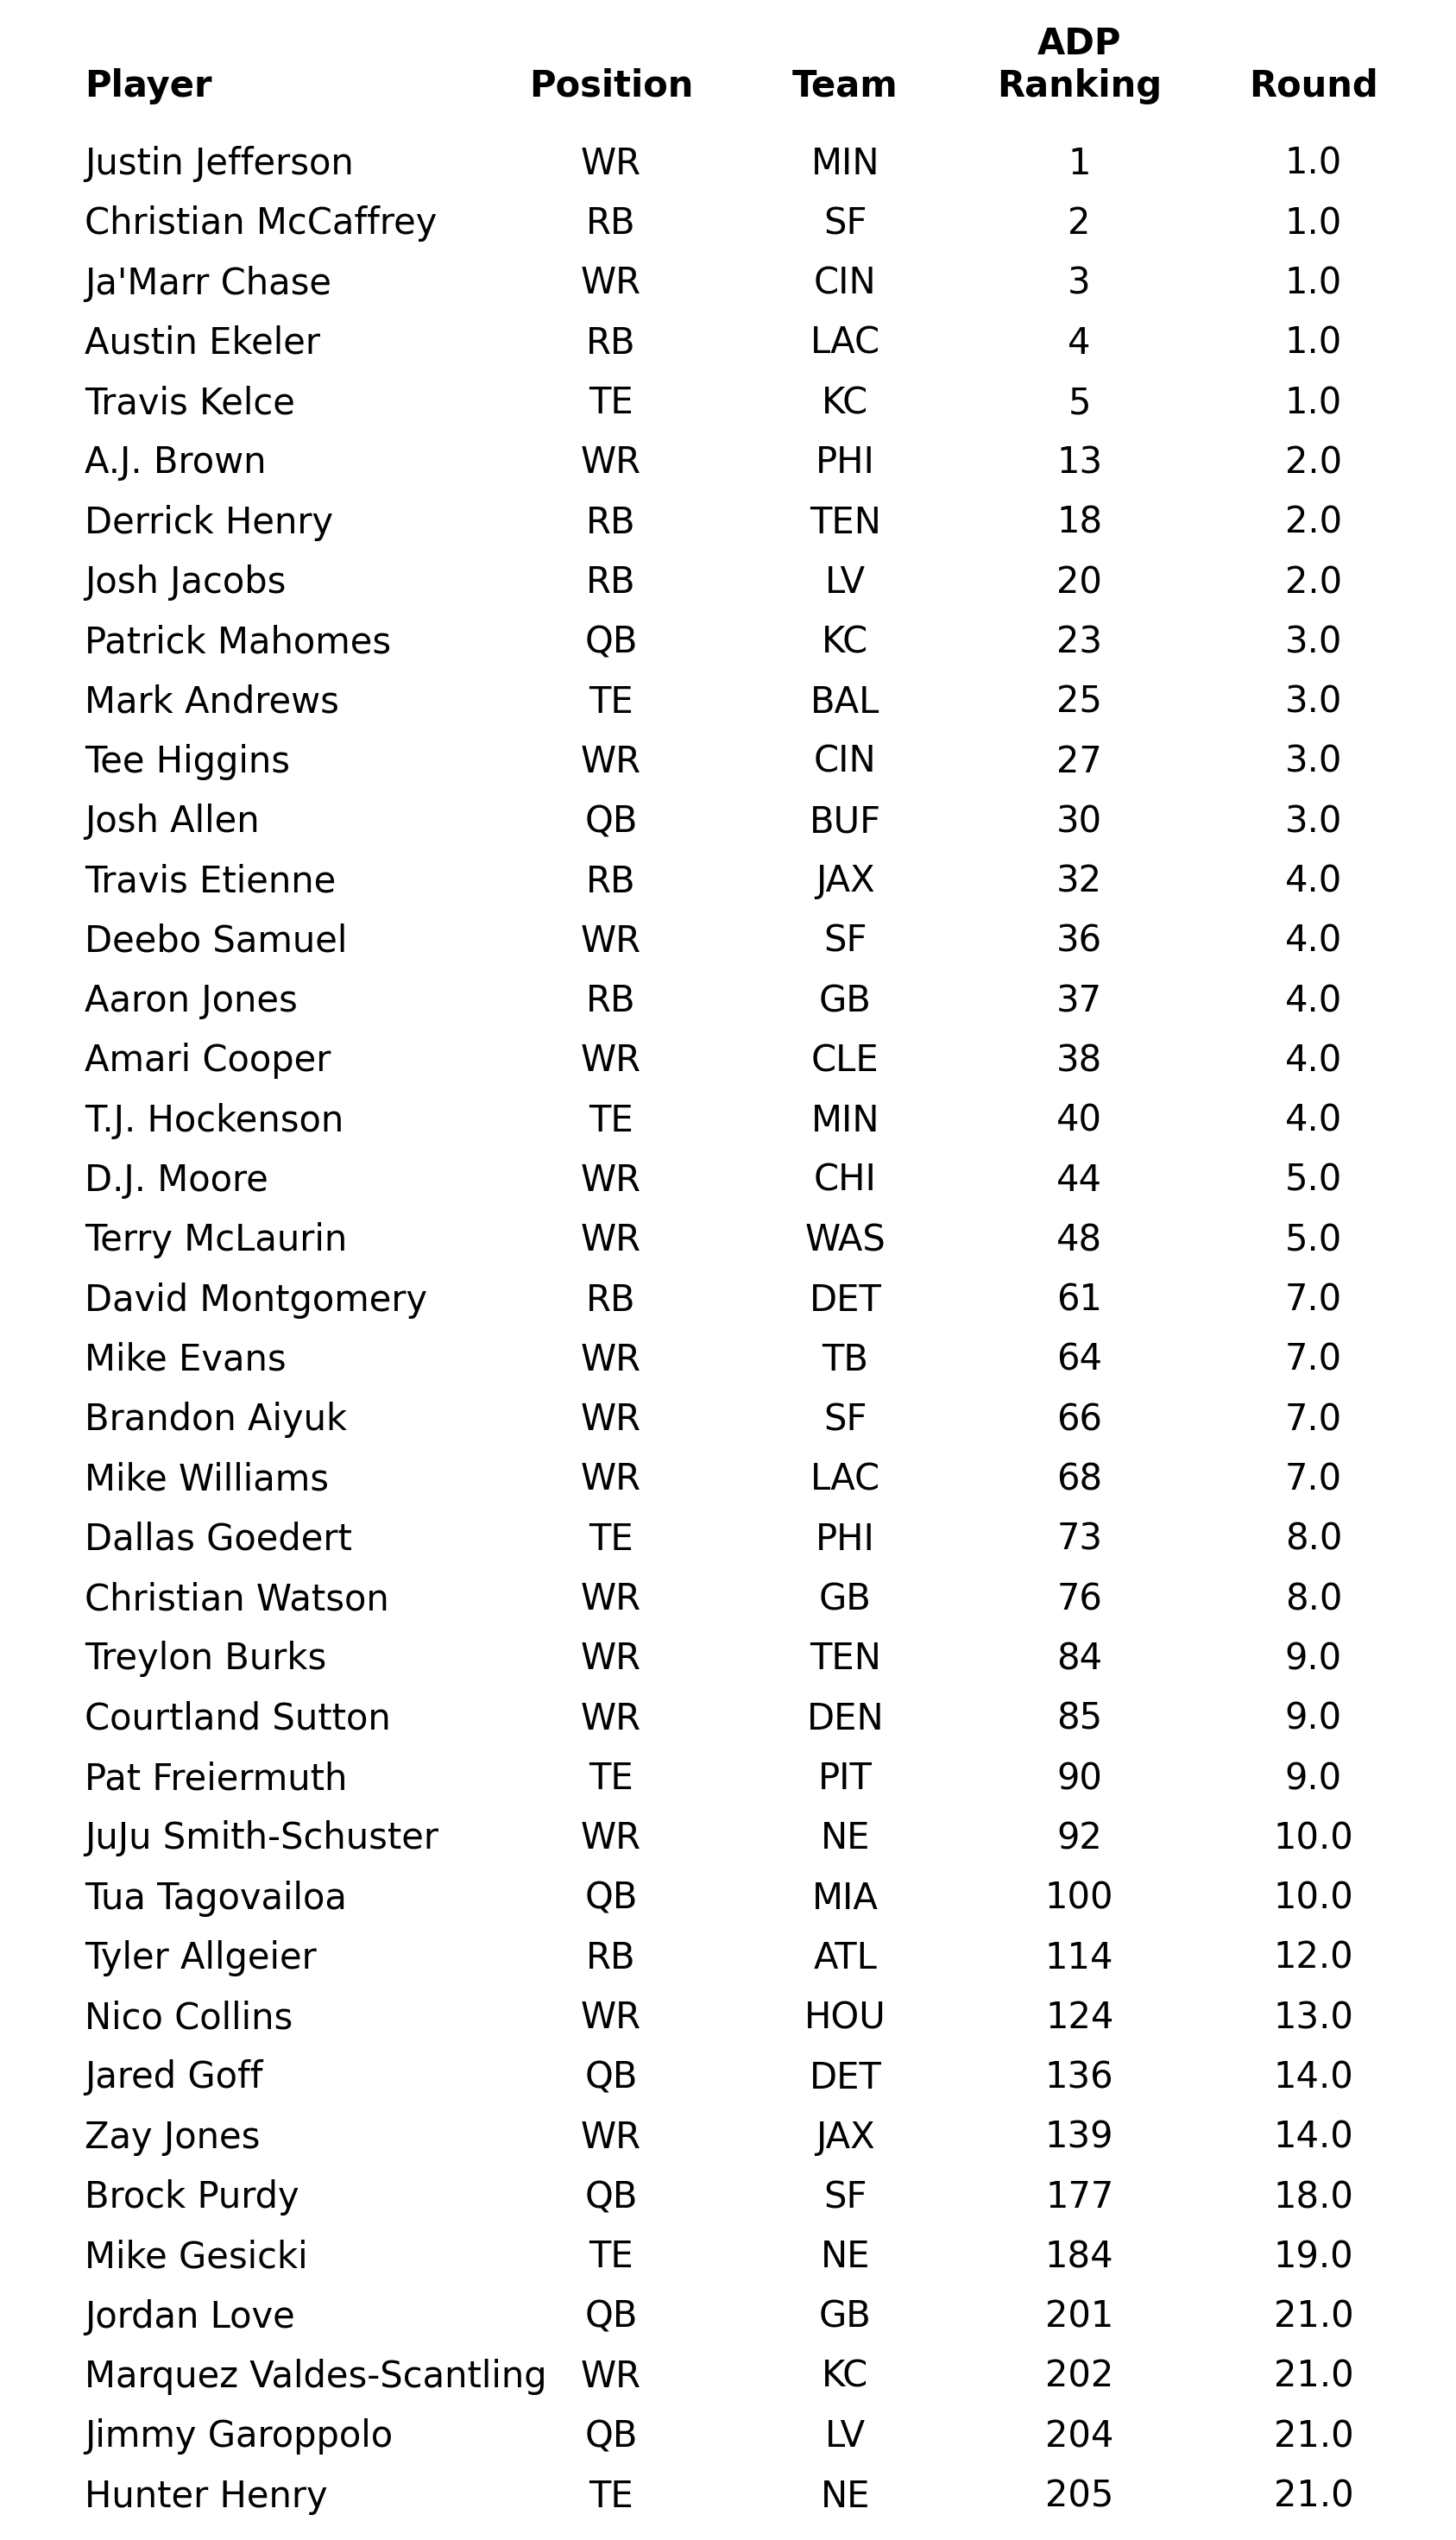

In [82]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7,12), dpi=300)
ax = plt.subplot()

all_players_w_adp_10team = pd.read_csv('fantasy_draft_guide/2023/draftguide_10team.csv')
all_players_w_adp_10team = all_players_w_adp_10team.drop(all_players_w_adp_10team.columns[0],axis=1)

all_players_w_adp_10team = all_players_w_adp_10team.sort_values('ADP_Ranking', ascending=True)

ncols = len(all_players_w_adp_10team.columns)
nrows = all_players_w_adp_10team.shape[0]

ax.set_xlim(0, ncols + 1)
ax.set_ylim(0, nrows)

positions = [0.25, 2.5, 3.5, 4.5, 5.5]
columns = all_players_w_adp_10team.columns

# Add table's main text
for i in range(nrows):
    for j, column in enumerate(columns):
        if j == 0:
            ha = 'left'
        else:
            ha = 'center'
        ax.annotate(
            xy=(positions[j], nrows-i-1),
            text=all_players_w_adp_10team[column].iloc[i],
            ha=ha,
            va='center'
        )

# Add column names
column_names = ['Player', 'Position', 'Team', 'ADP\nRanking', 'Round']
for index, c in enumerate(column_names):
        if index == 0:
            ha = 'left'
        else:
            ha = 'center'
        ax.annotate(
            xy=(positions[index], nrows),
            text=column_names[index],
            ha=ha,
            va='bottom',
            weight='bold'
        )

# Add dividing lines
#ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [nrows, nrows], lw=1.5, color='black', marker='', zorder=4)
#ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [0, 0], lw=1.5, color='black', marker='', zorder=4)
#for x in range(1, nrows):
#    ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [x, x], lw=1.15, color='gray', ls=':', zorder=3 , marker='')


ax.set_axis_off()
#ax.set_title('Projected Superstar Fantasy Performers')
plt.savefig(
    'fantasy_draft_guide/2023/all_selected_players.png',
    dpi=300,
    transparent=True,
    bbox_inches='tight',
)

In [85]:
def pretty_table(df, filename):
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(7,12), dpi=300)
    ax = plt.subplot()

    ncols = len(df.columns)
    nrows = df.shape[0]

    ax.set_xlim(0, ncols + 1)
    ax.set_ylim(0, nrows)

    positions = [0.25, 2.5, 3.5, 4.5, 5.5]
    columns = df.columns

    # Add table's main text
    for i in range(nrows):
        for j, column in enumerate(columns):
            if j == 0:
                ha = 'left'
            else:
                ha = 'center'
            ax.annotate(
                xy=(positions[j], nrows-i-0.5),
                text=df[column].iloc[i],
                ha=ha,
                va='center'
            )

    # Add column names
    column_names = ['Player', 'Position', 'Team', 'ADP\nRanking', 'Round']
    for index, c in enumerate(column_names):
            if index == 0:
                ha = 'left'
            else:
                ha = 'center'
            ax.annotate(
                xy=(positions[index], nrows),
                text=column_names[index],
                ha=ha,
                va='bottom',
                weight='bold'
            )

    # Add dividing lines
    ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [nrows, nrows], lw=1.5, color='black', marker='', zorder=4)
    ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [0, 0], lw=1.5, color='black', marker='', zorder=4)
    for x in range(1, nrows):
        ax.plot([ax.get_xlim()[0], ax.get_xlim()[1]], [x, x], lw=1.15, color='gray', ls=':', zorder=3 , marker='')


    ax.set_axis_off()
    #ax.set_title('Projected Superstar Fantasy Performers')
    plt.savefig(
        filename,
        dpi=300,
        transparent=True,
        bbox_inches='tight',
    )

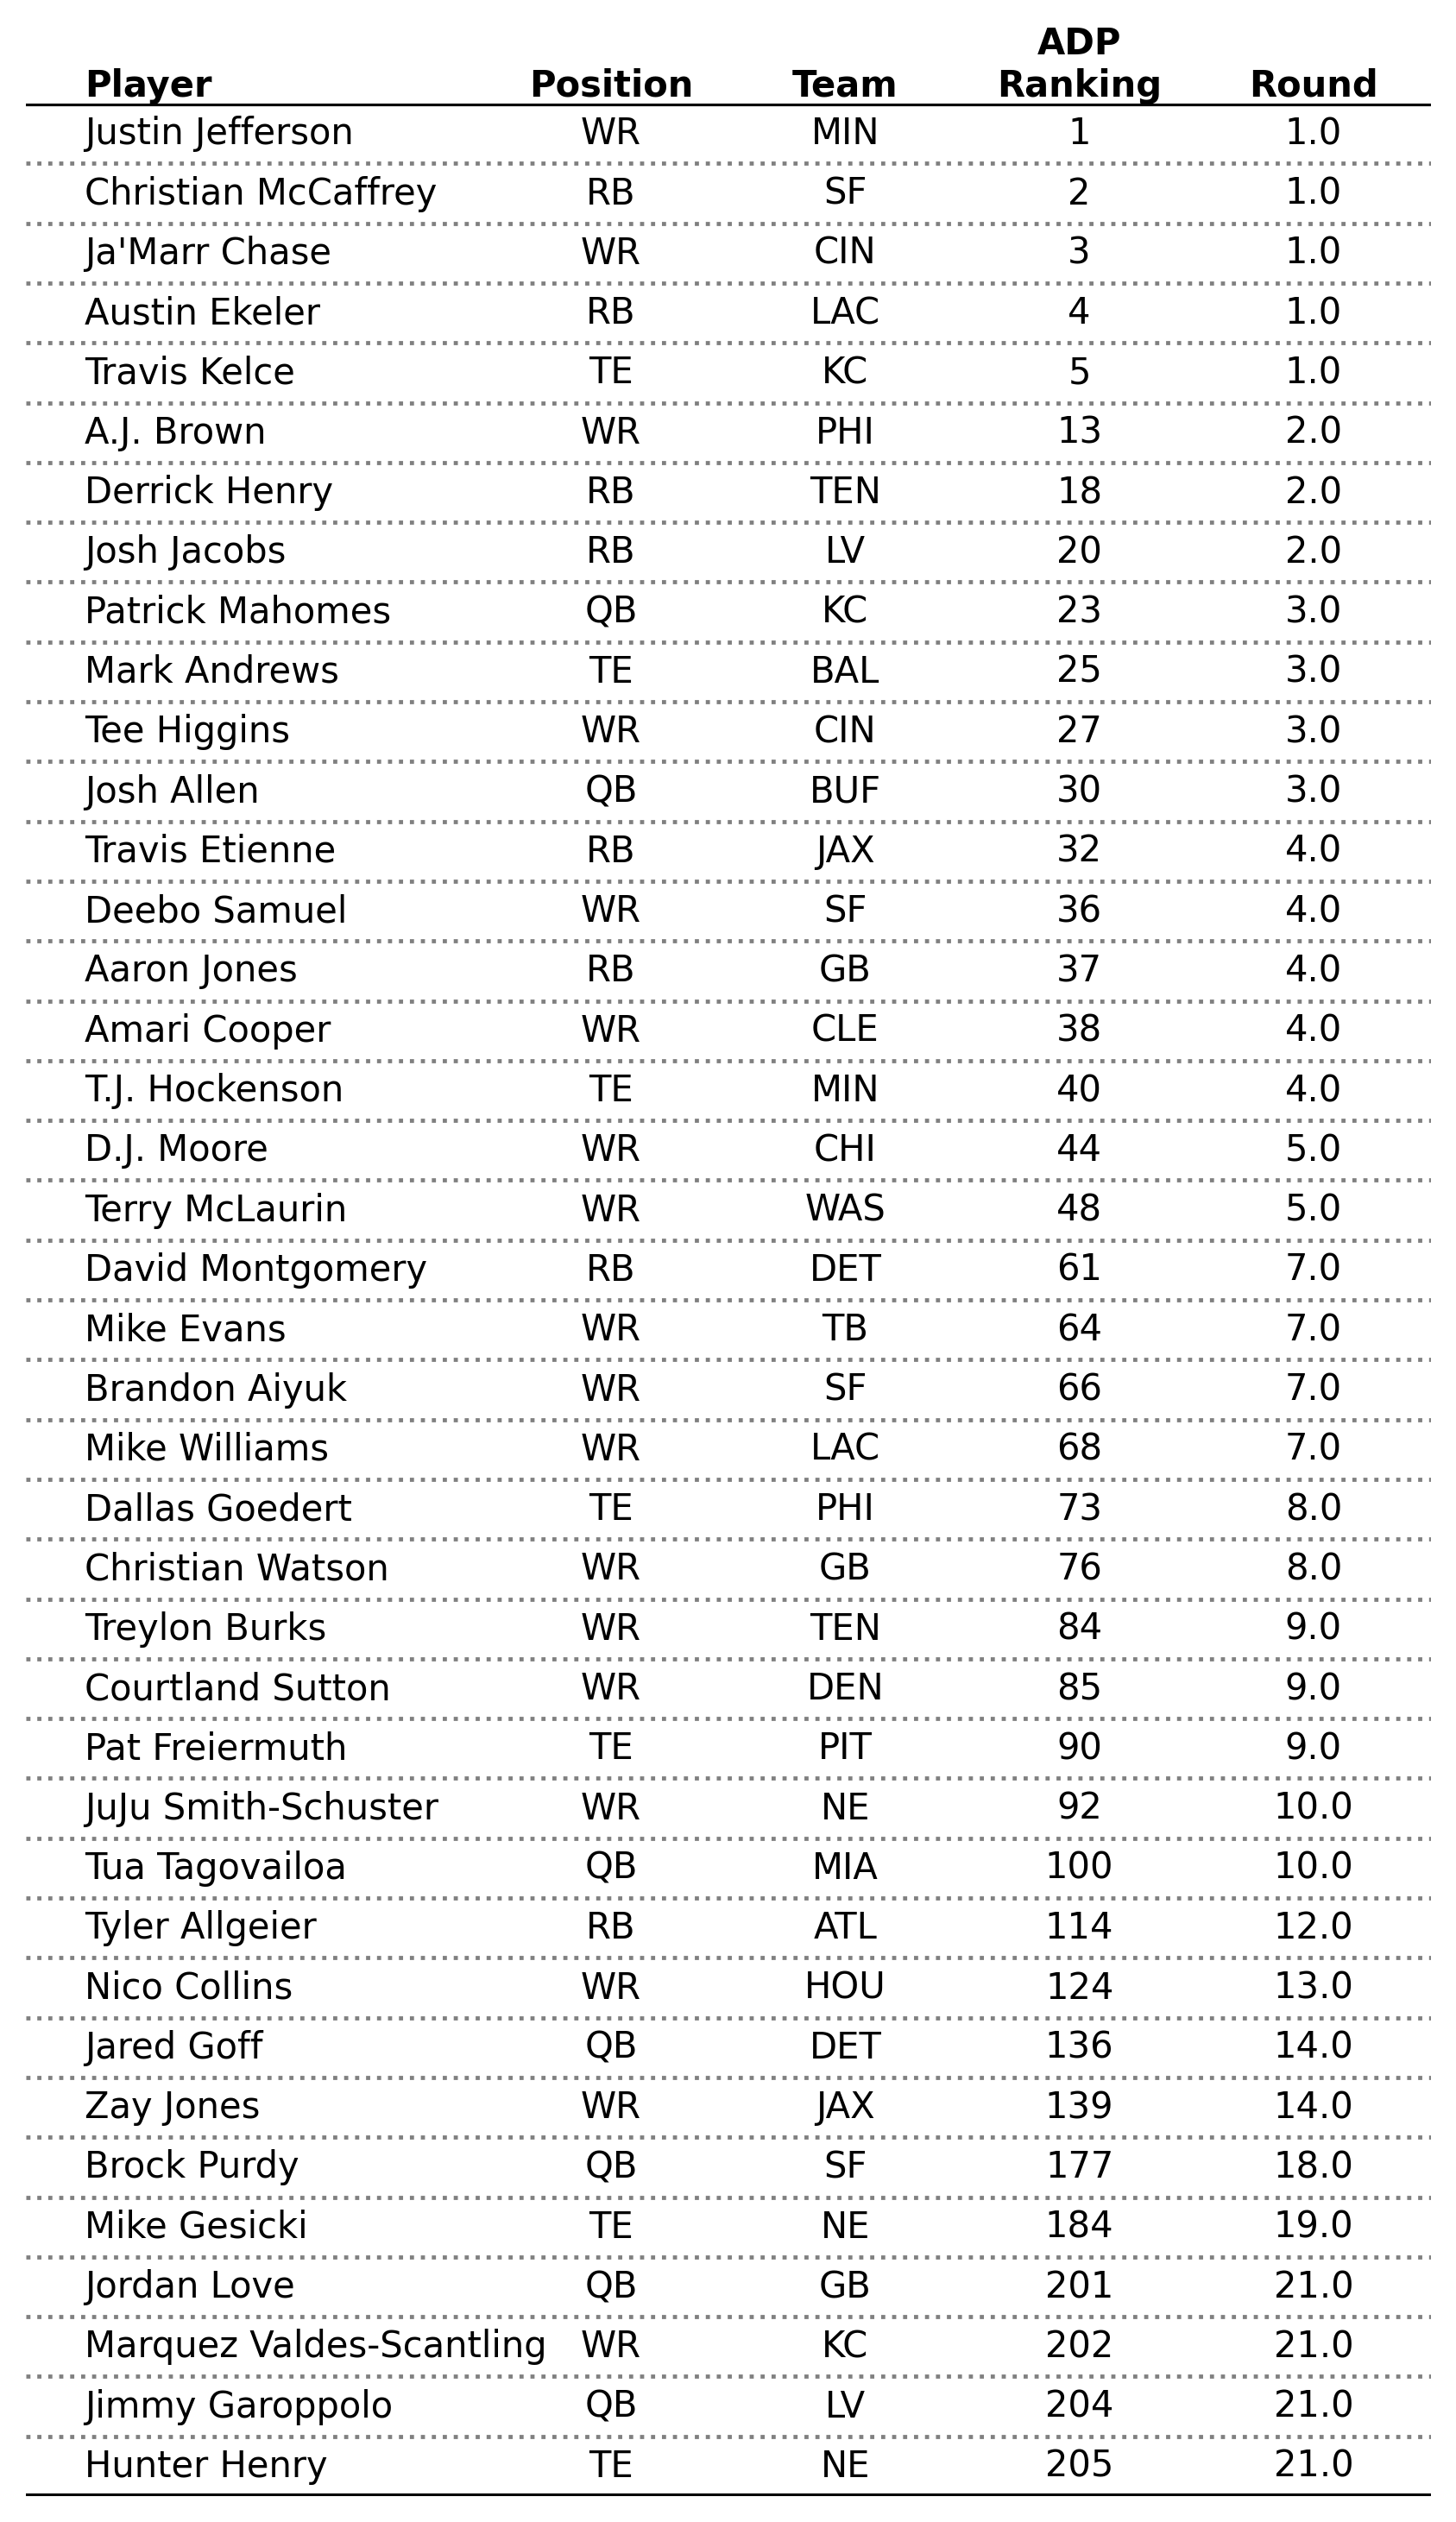

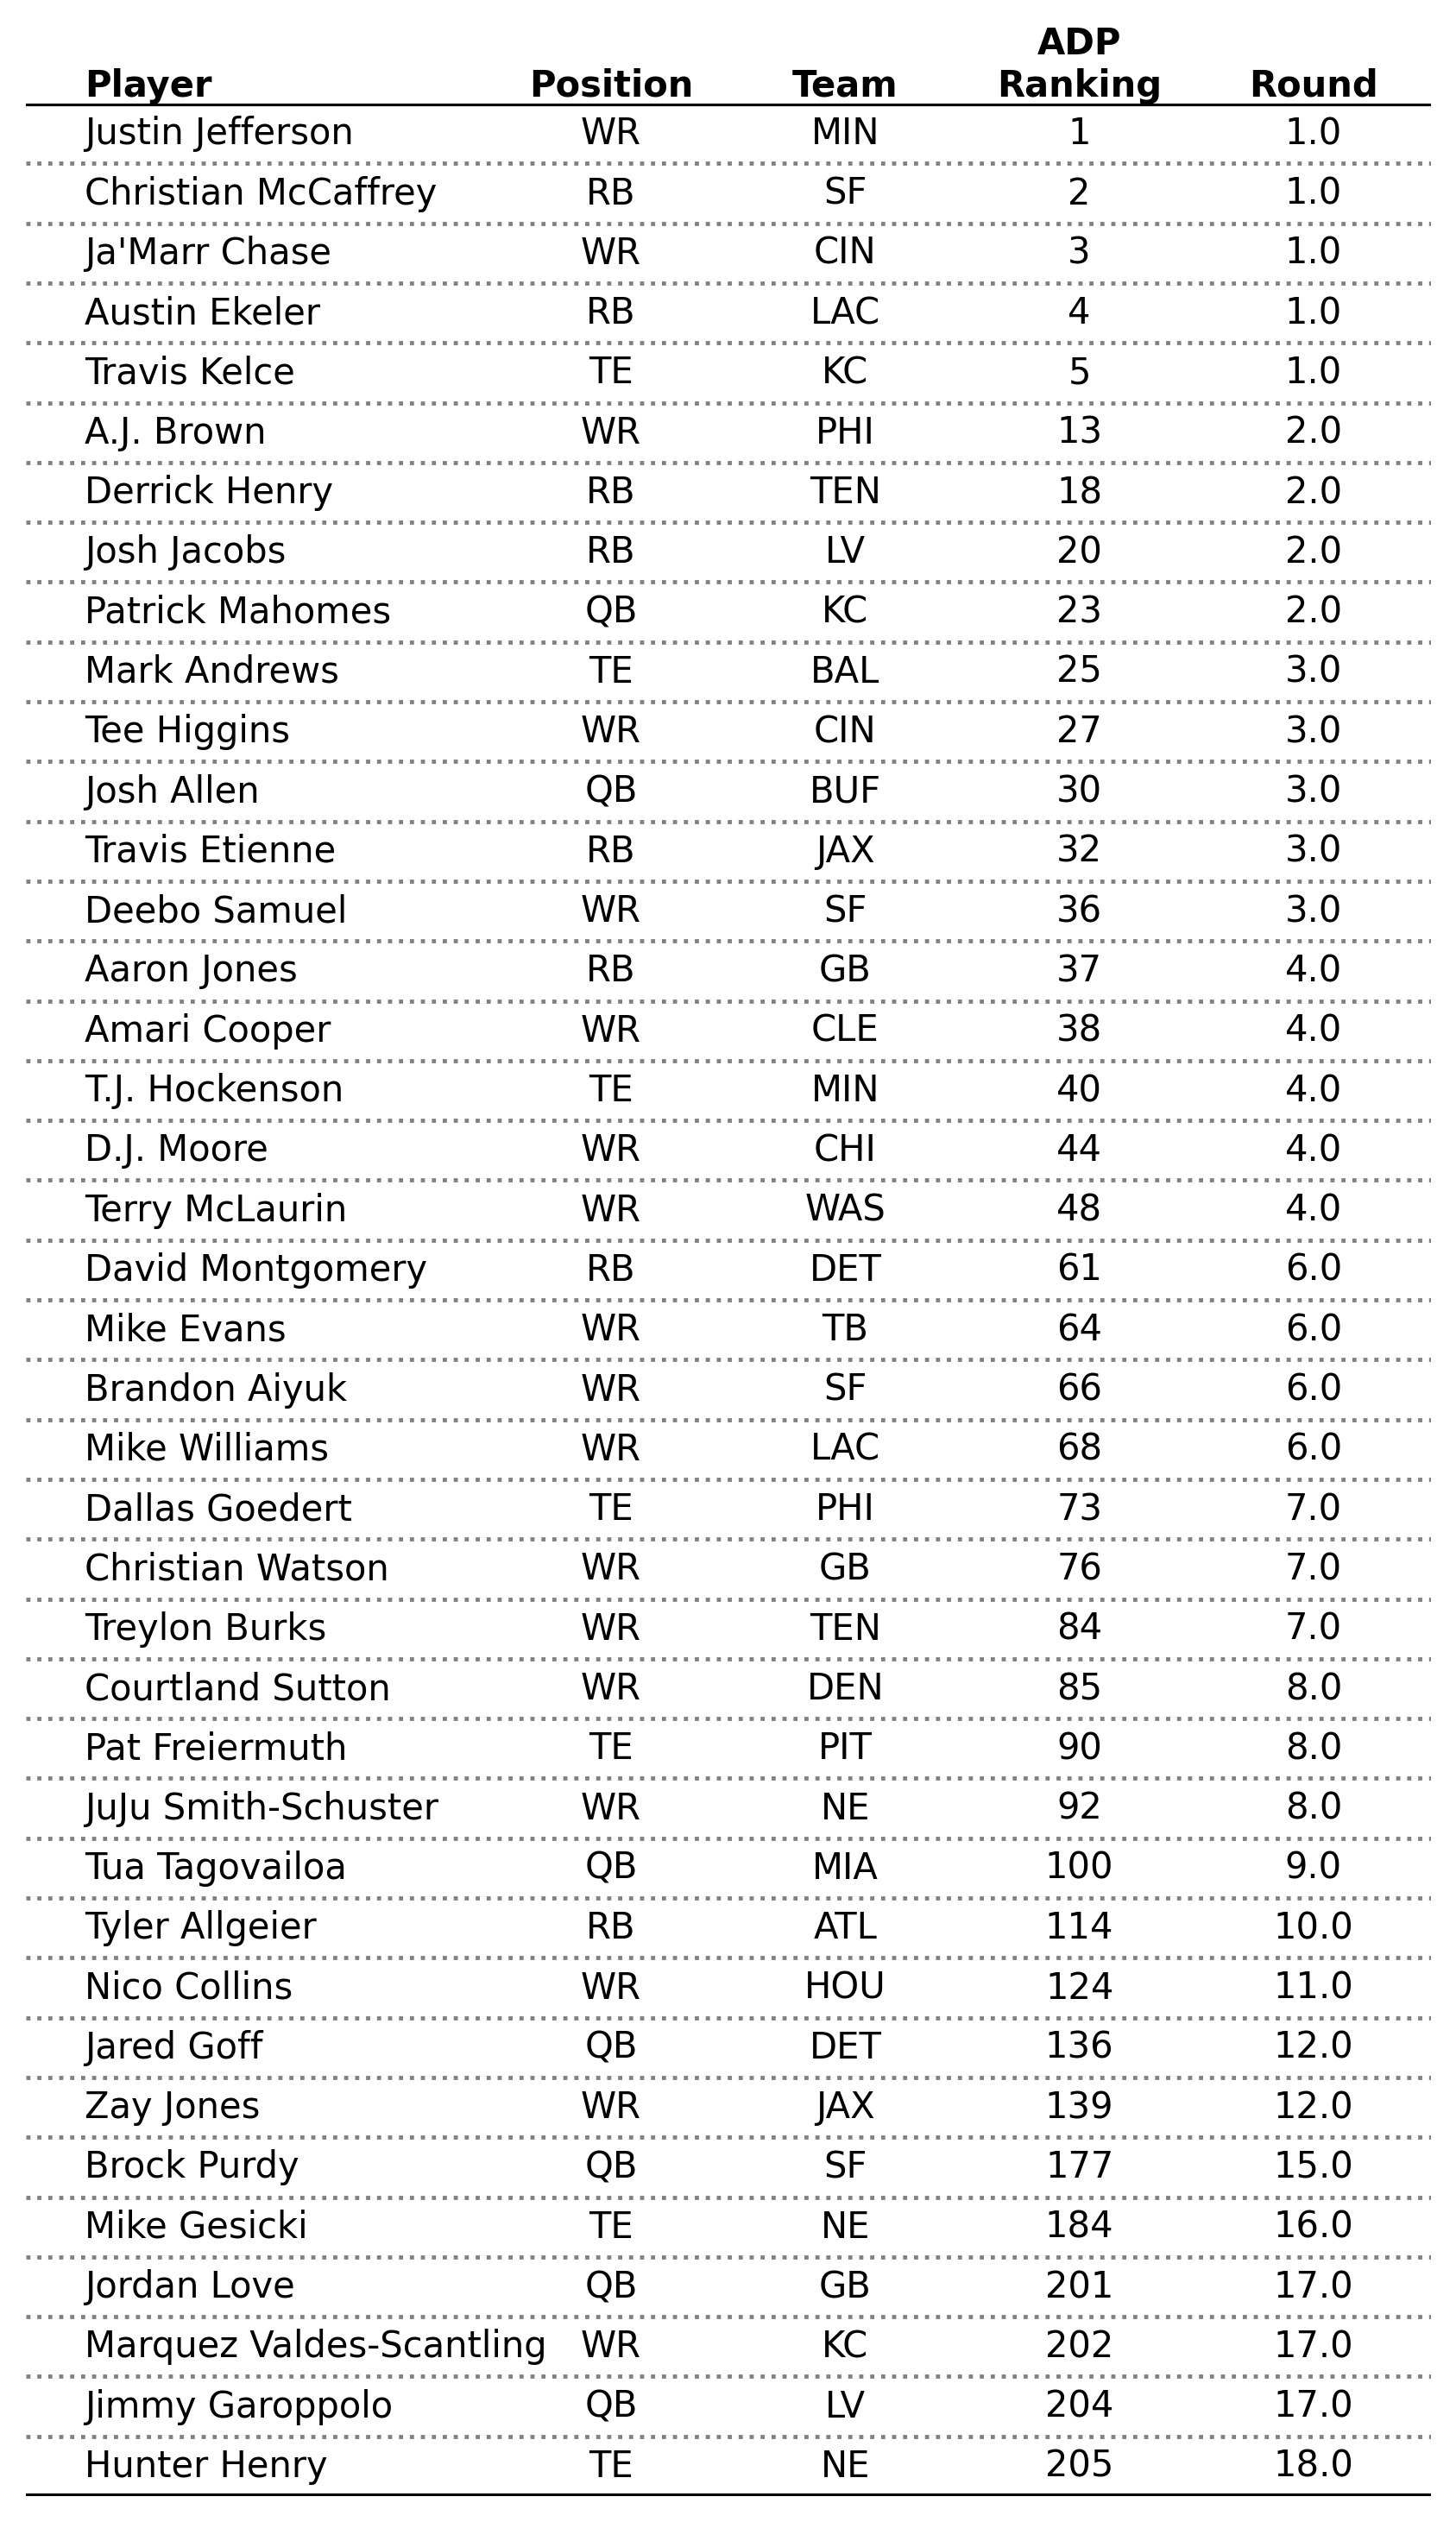

In [86]:
all_players_w_adp_10team = pd.read_csv('fantasy_draft_guide/2023/draftguide_10team.csv')
all_players_w_adp_10team = all_players_w_adp_10team.drop(all_players_w_adp_10team.columns[0],axis=1)
all_players_w_adp_10team = all_players_w_adp_10team.sort_values('ADP_Ranking', ascending=True)
pretty_table(all_players_w_adp_10team,'fantasy_draft_guide/2023/all_selected_players_10team_prettier.png')

all_players_w_adp_12team = pd.read_csv('fantasy_draft_guide/2023/draftguide_12team.csv')
all_players_w_adp_12team = all_players_w_adp_12team.drop(all_players_w_adp_12team.columns[0],axis=1)
all_players_w_adp_12team = all_players_w_adp_12team.sort_values('ADP_Ranking', ascending=True)
pretty_table(all_players_w_adp_12team,'fantasy_draft_guide/2023/all_selected_players_12team_prettier.png')

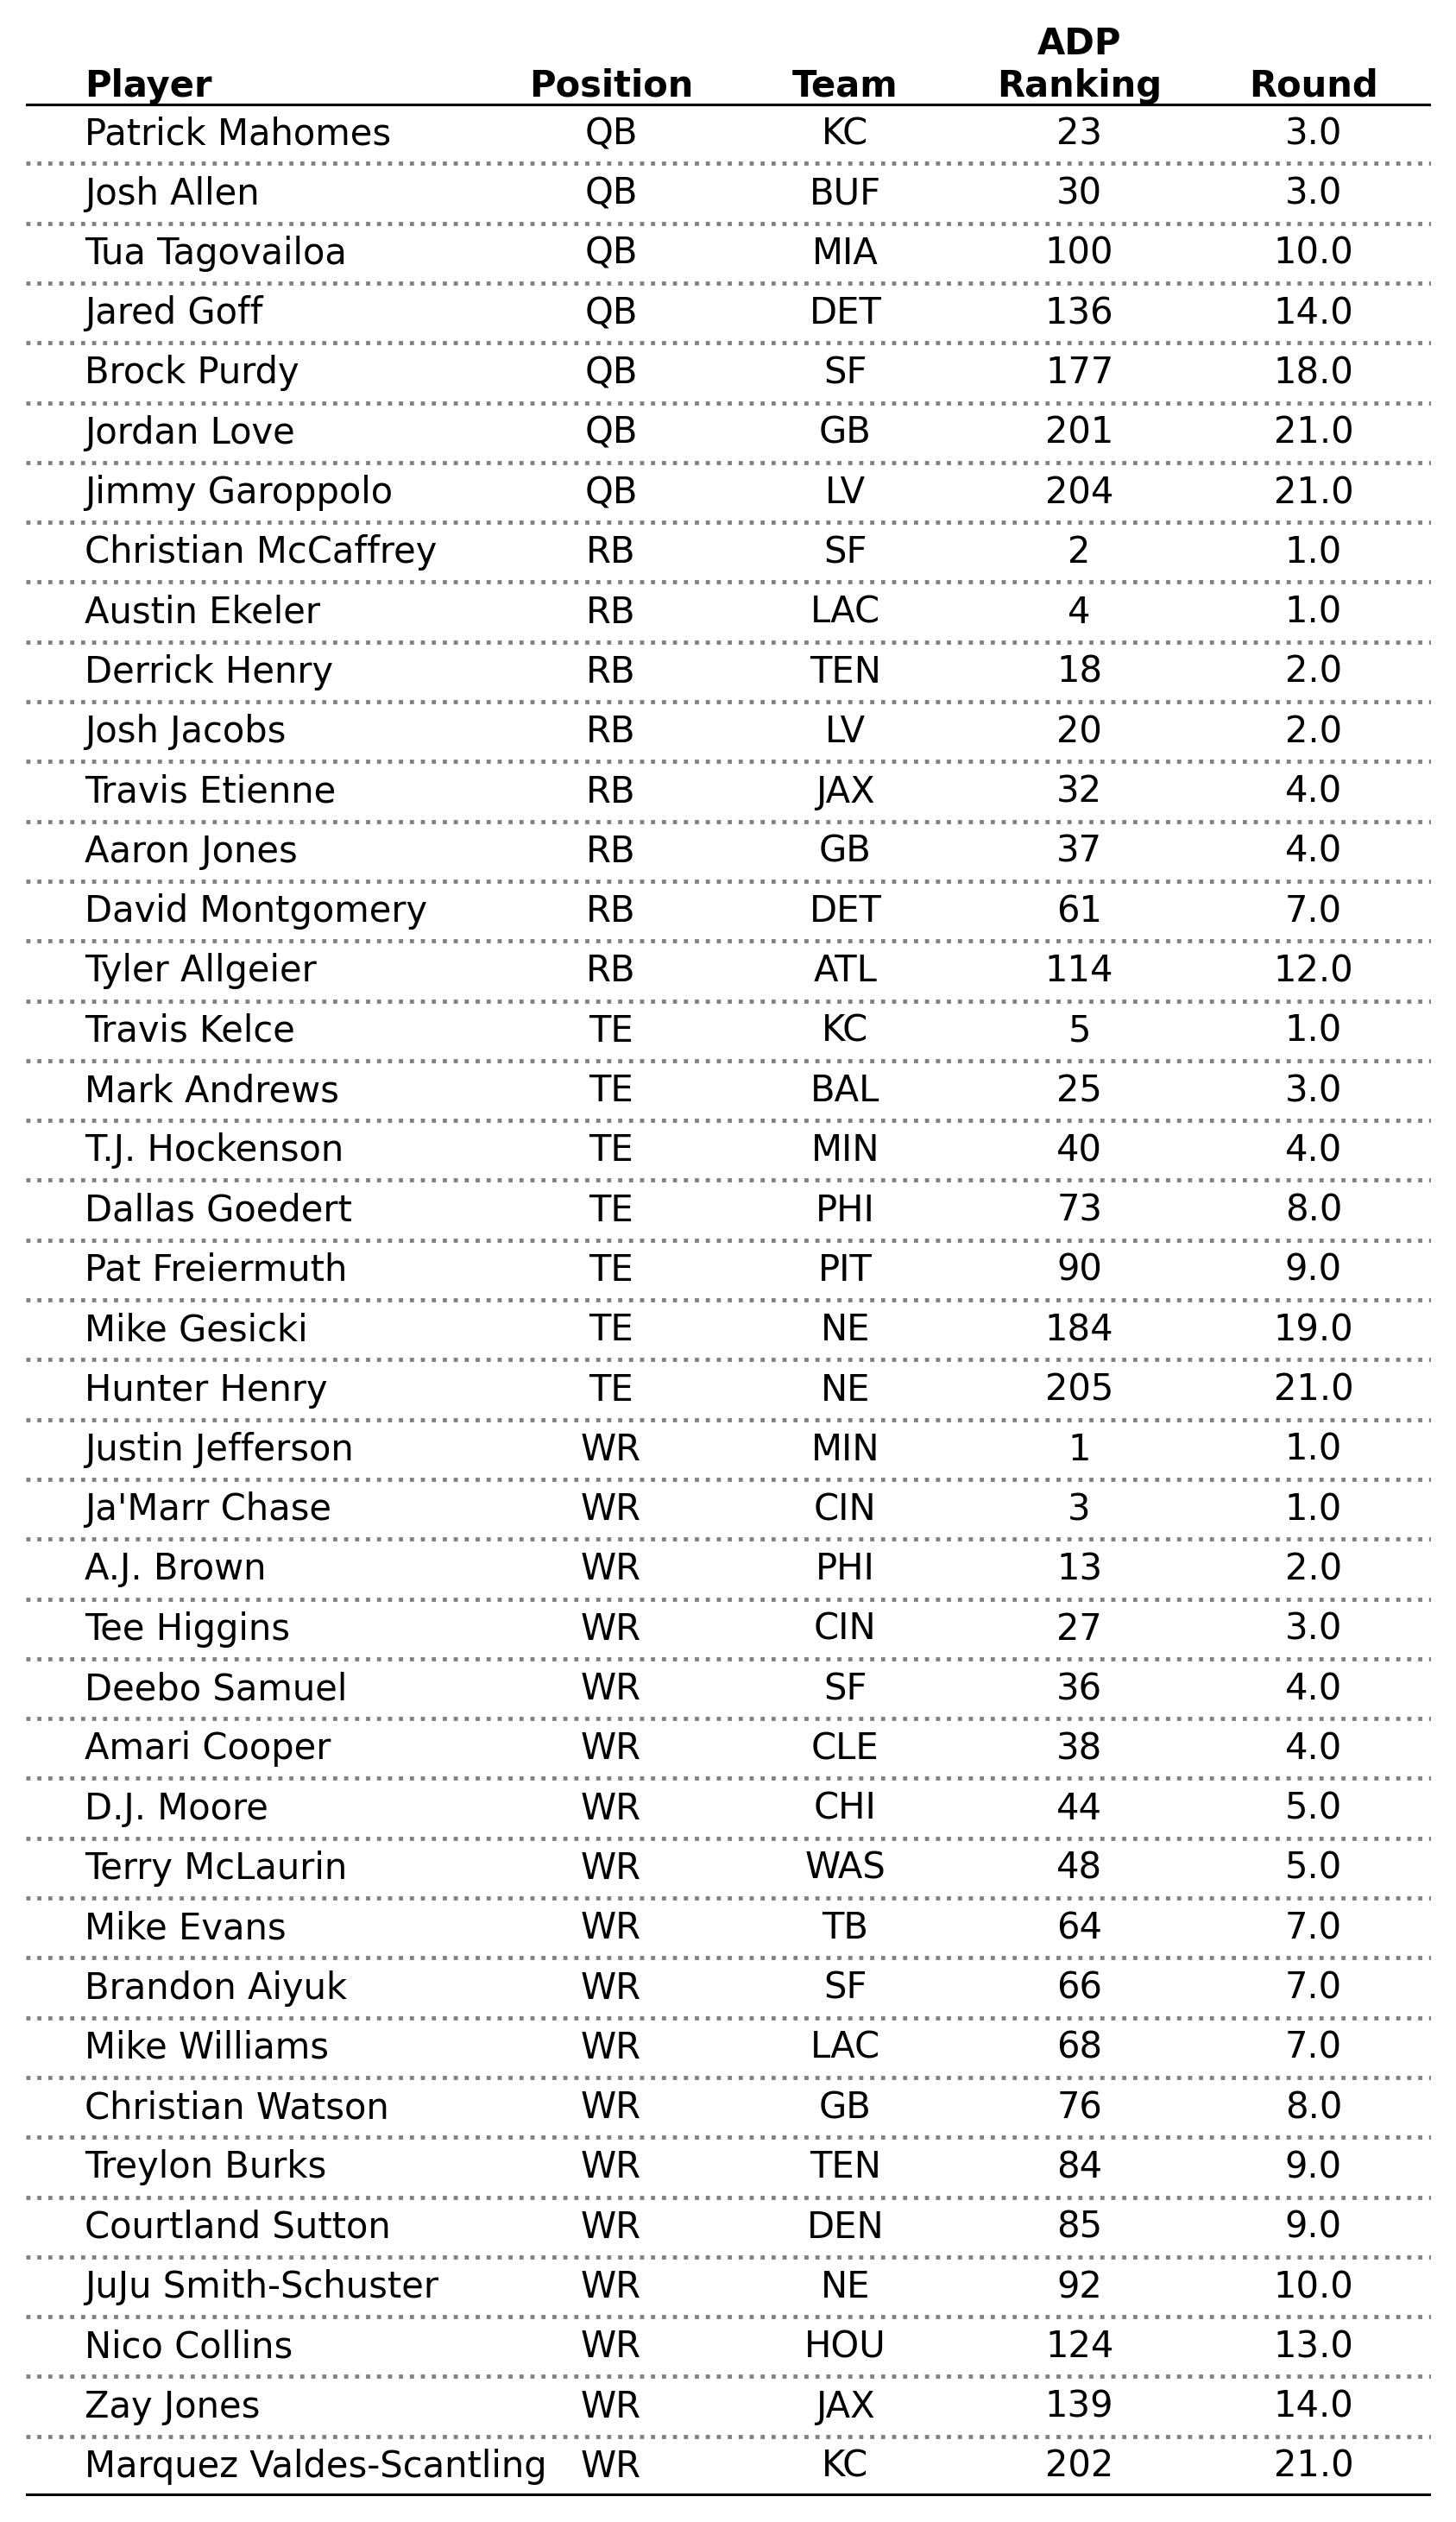

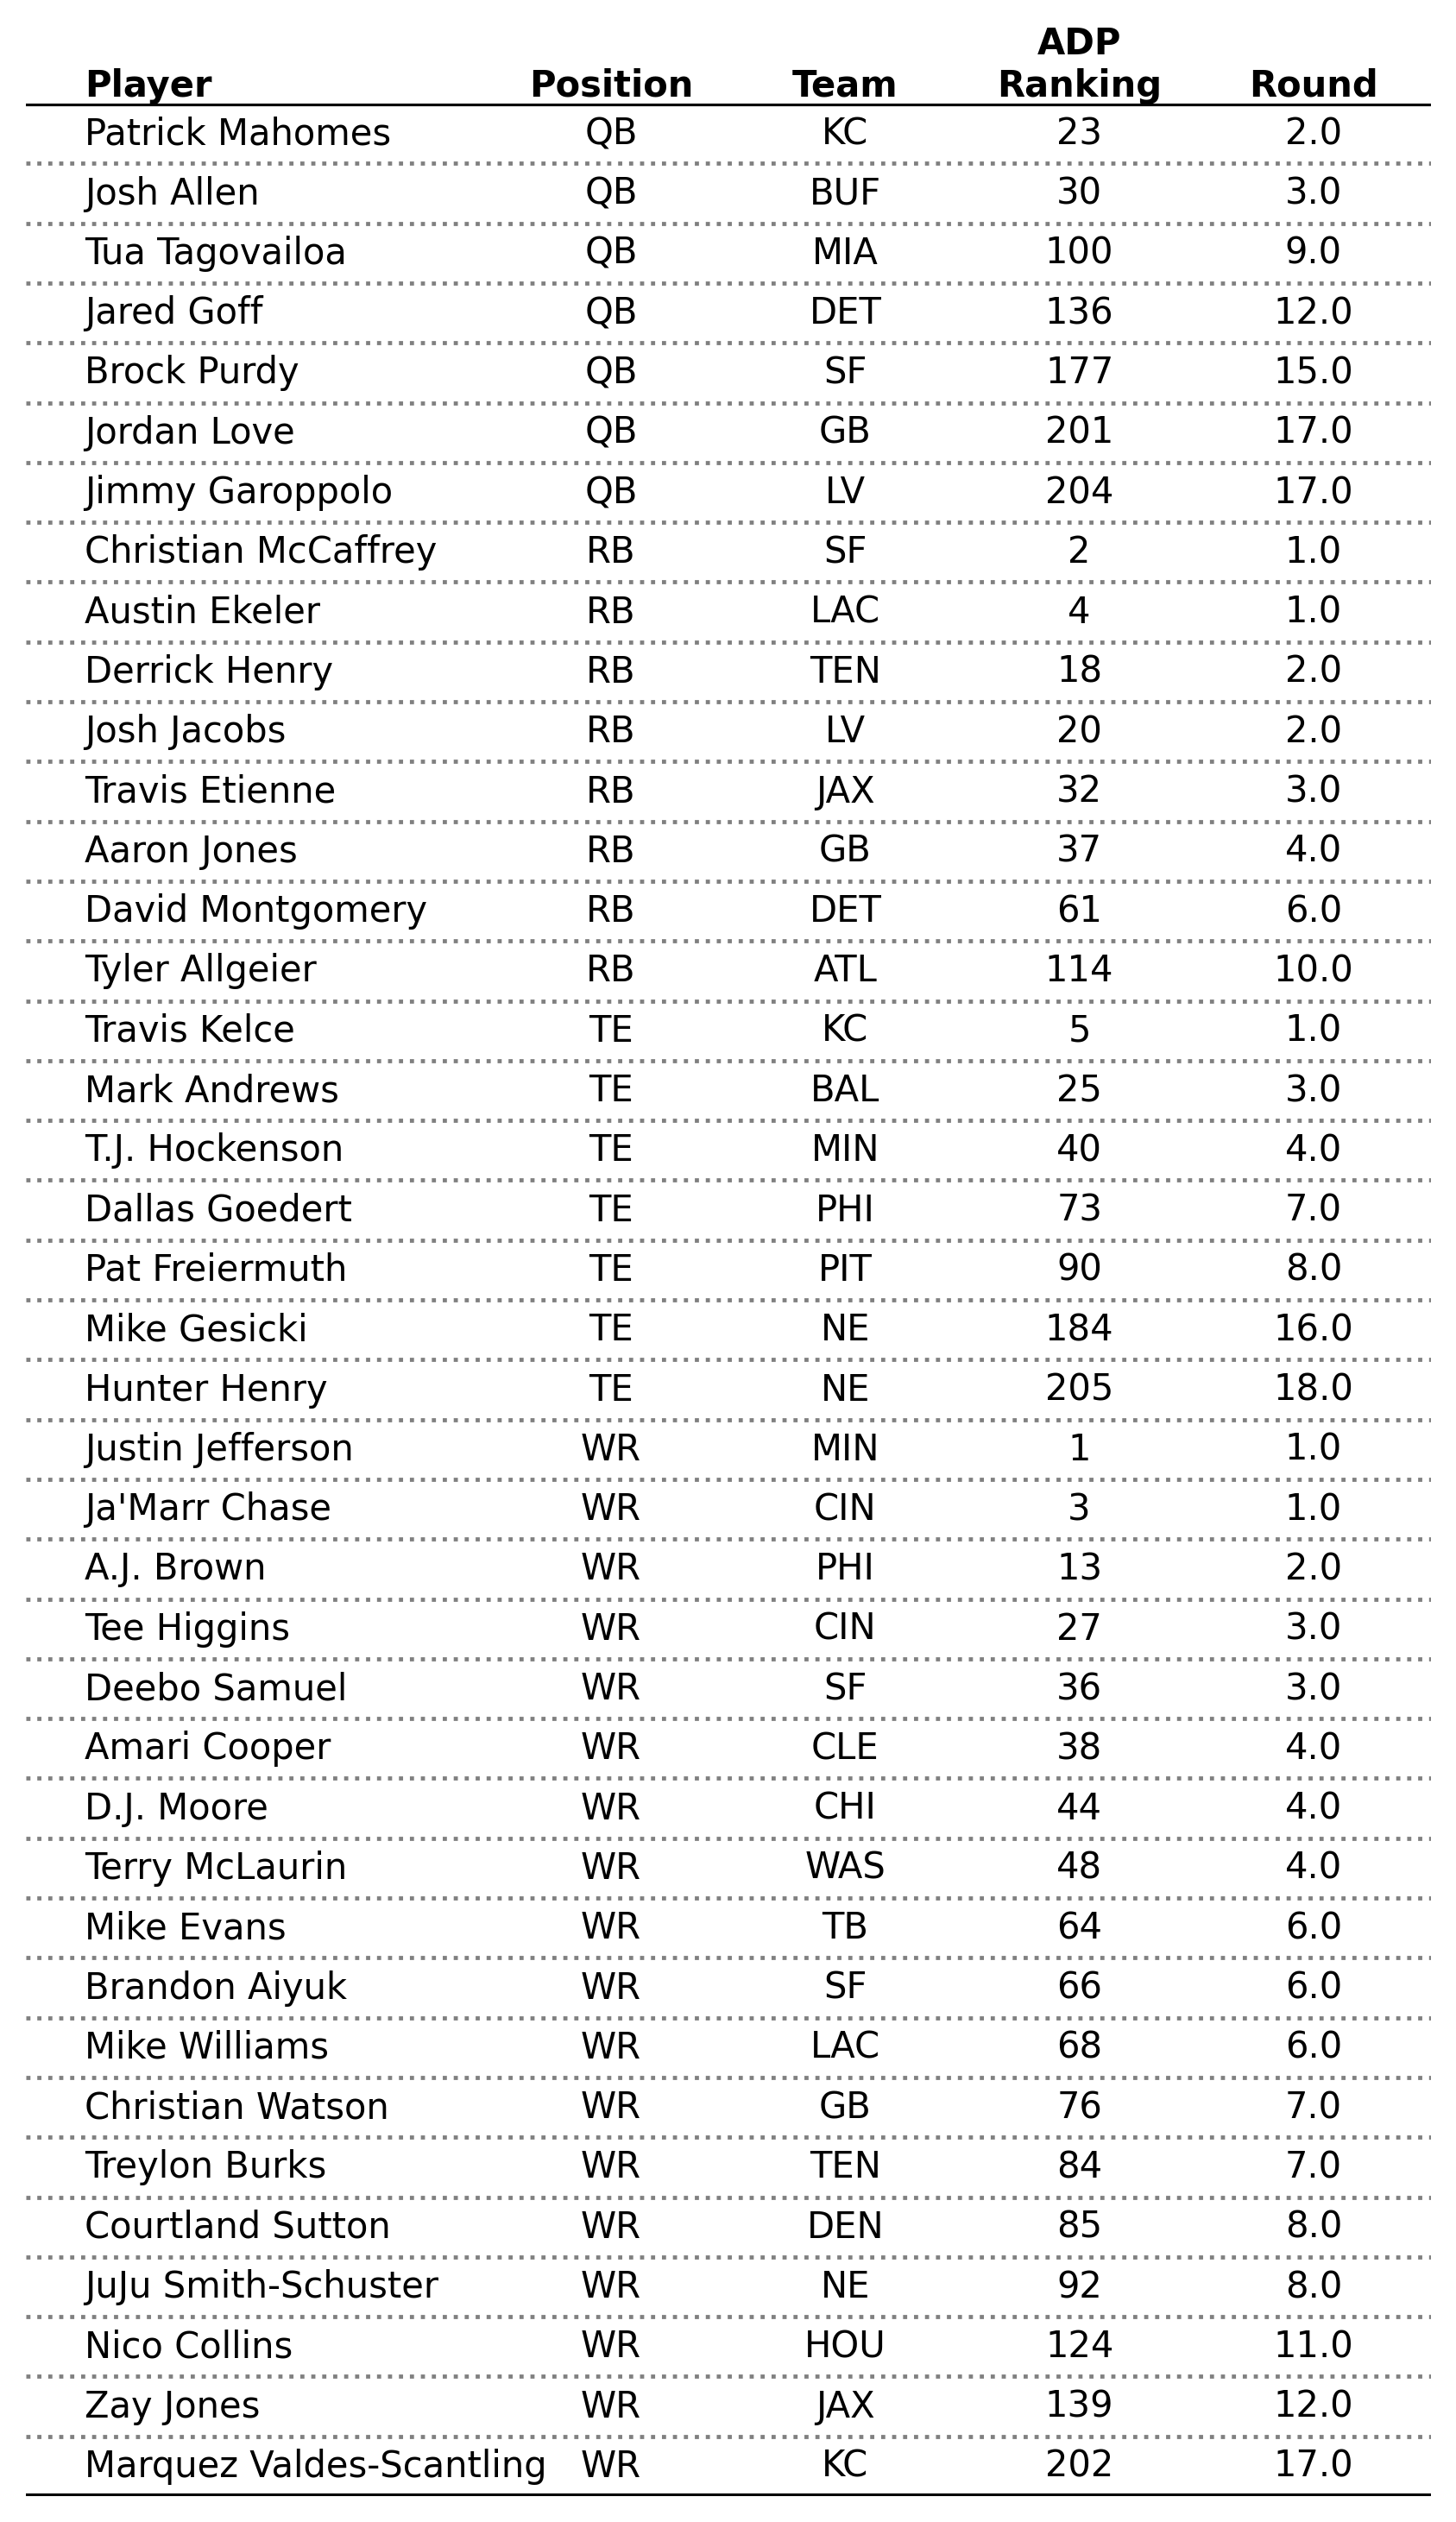

In [87]:
all_players_w_adp_10team = pd.read_csv('fantasy_draft_guide/2023/draftguide_10team.csv')
all_players_w_adp_10team = all_players_w_adp_10team.drop(all_players_w_adp_10team.columns[0],axis=1)
all_players_w_adp_10team = all_players_w_adp_10team.sort_values(['Position','ADP_Ranking'], ascending=True)
pretty_table(all_players_w_adp_10team,'fantasy_draft_guide/2023/all_selected_players_10team_by_position.png')

all_players_w_adp_12team = pd.read_csv('fantasy_draft_guide/2023/draftguide_12team.csv')
all_players_w_adp_12team = all_players_w_adp_12team.drop(all_players_w_adp_12team.columns[0],axis=1)
all_players_w_adp_12team = all_players_w_adp_12team.sort_values(['Position','ADP_Ranking'], ascending=True)
pretty_table(all_players_w_adp_12team,'fantasy_draft_guide/2023/all_selected_players_12team_by_position.png')

In [25]:
import json
import pandas as pd
from fpdf import FPDF
from datetime import date
import plotly.graph_objects as go
import plotly.express as px
from urllib.request import urlopen
import smtplib
from pathlib import Path
from email.mime.multipart import MIMEMultipart
from email.mime.base import MIMEBase
from email.mime.text import MIMEText
from email.utils import COMMASPACE, formatdate
from email import encoders

all_players_w_adp_10team = pd.read_csv('fantasy_draft_guide/2023/draftguide_10team.csv')
all_players_w_adp_10team = all_players_w_adp_10team.drop(all_players_w_adp_10team.columns[0],axis=1)
#all_players_w_adp_12team = pd.read_csv('fantasy_draft_guide/2023/draftguide_12team.csv')

fig = go.Figure(
    data=[go.Table(
    header=dict(values=list(all_players_w_adp_10team.columns),
                fill_color='paleturquoise',
                align='left',),
    cells=dict(values=all_players_w_adp_10team.transpose().values.tolist(),
               fill_color='lavender',
               align='left'))
])

fig.show()

In [26]:
import plotly.figure_factory as ff

fig =  ff.create_table(all_players_w_adp_10team)
fig.add_table()
fig.show()

In [34]:

import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=5, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.03,
    specs=[[{"type": "table"}],
        [{"type": "table"}],
        [{"type": "table"}],
        [{"type": "table"}],
        [{"type": "table"}]]
)

fig.add_trace(
    go.Table(
    header=dict(values=list(all_players_w_adp_10team.columns),
                fill_color='paleturquoise',
                align='left',),
    cells=dict(values=all_players_w_adp_10team.transpose().values.tolist(),
               fill_color='lavender',
               align='left')
    ),
    row=1, col=1
)

fig.add_trace(
    go.Table(
    header=dict(values=list(all_players_w_adp_10team[all_players_w_adp_10team['Position'] == 'QB'].columns),
                fill_color='paleturquoise',
                align='left',),
    cells=dict(values=all_players_w_adp_10team[all_players_w_adp_10team['Position'] == 'QB'].transpose().values.tolist(),
               fill_color='lavender',
               align='left')
    ),
    row=2, col=1
)

fig.add_trace(
    go.Table(
    header=dict(values=list(all_players_w_adp_10team[all_players_w_adp_10team['Position'] == 'RB'].columns),
                fill_color='paleturquoise',
                align='left',),
    cells=dict(values=all_players_w_adp_10team[all_players_w_adp_10team['Position'] == 'RB'].transpose().values.tolist(),
               fill_color='lavender',
               align='left')
    ),
    row=3, col=1
)

fig.add_trace(
    go.Table(
    header=dict(values=list(all_players_w_adp_10team[all_players_w_adp_10team['Position'] == 'WR'].columns),
                fill_color='lightgreen',
                align='left',),
    cells=dict(values=all_players_w_adp_10team[all_players_w_adp_10team['Position'] == 'WR'].transpose().values.tolist(),
               fill_color='lightgray',
               align='left')
    ),
    row=4, col=1
)

fig.add_trace(
    go.Table(
    header=dict(values=list(all_players_w_adp_10team[all_players_w_adp_10team['Position'] == 'TE'].columns),
                fill_color='paleturquoise',
                align='left',),
    cells=dict(values=all_players_w_adp_10team[all_players_w_adp_10team['Position'] == 'TE'].transpose().values.tolist(),
               fill_color='lavender',
               align='left')
    ),
    row=5, col=1
)

fig.update_layout(
    height=800,
    showlegend=False,
    title_text="2023 Fantasy Football - Draft these Players!",
)

#fig.show()

import plotly.graph_objects as go # or plotly.express as px
#fig = go.Figure() # or any Plotly Express function e.g. px.bar(...)
# fig.add_trace( ... )
# fig.update_layout( ... )

from dash import Dash, dcc, html

app = Dash()
app.layout = html.Div([
    dcc.Graph(figure=fig)
])

app.run_server(debug=True, use_reloader=False)  # Turn off reloader if inside Jupyter

In [29]:
import plotly.graph_objects as go # or plotly.express as px
#fig = go.Figure() # or any Plotly Express function e.g. px.bar(...)
# fig.add_trace( ... )
# fig.update_layout( ... )

from dash import Dash, dcc, html

app = Dash()
app.layout = html.Div([
    dcc.Graph(figure=fig)
])

app.run_server(debug=True, use_reloader=False)  # Turn off reloader if inside Jupyter

In [ ]:
import json
import pandas as pd
from fpdf import FPDF
from datetime import date
import plotly.graph_objects as go
import plotly.express as px
from urllib.request import urlopen
import smtplib
from pathlib import Path
from email.mime.multipart import MIMEMultipart
from email.mime.base import MIMEBase
from email.mime.text import MIMEText
from email.utils import COMMASPACE, formatdate
from email import encoders

datasets = \
{
    "datasets": [
    {
            "paths": ["dataframe_csvs/joined_viz_table.csv"],
            "plots":[
                {
                    "plot_type": "choropleth",
                    "args": {
                        "title": "Occupancy Rate Changes W/W",
                        "locations":"zipcode", # use with OpenDataDE geojsons
                        #"locations":"fips", # use with plotly geojsons
                        "color": "occ_pct_change",
                        "color_continuous_scale": "RdYlGn",
                        "featureidkey": "properties.ZCTA5CE10",
                        "range_color": [-100,100],
                        "scope": "usa",
                        "html_filename": "html_plots/choropleth_occ_rate_config_generated_cloud_100pctrange.html",
                        "png_filename": "png_plots/choropleth_occ_rate_config_generated_cloud_100pctrange.png"
                    }
                }]
    },
    {
            "paths": ["dataframe_csvs/joined_viz_table.csv"],
            "plots":[
                {
                    "plot_type": "choropleth",
                    "args": {
                        "title": "Avg Nightly Price Changes W/W",
                        "locations":"zipcode", # use with OpenDataDE geojsons
                        #"locations":"fips", # use with plotly geojsons
                        "color": "avg_nightly_price_pct_change",
                        "color_continuous_scale": "RdYlGn",
                        "featureidkey": "properties.ZCTA5CE10",
                        "range_color": [-100,100],
                        "scope": "usa",
                        "html_filename": "html_plots/choropleth_price_config_generated_cloud_100pctrange.html",
                        "png_filename": "png_plots/choropleth_price_config_generated_cloud_100pctrange.png"
                    }
                }]
    },
    {
            "paths": ['dataframe_csvs/joined_viz_table.csv'],
            "plots": [{
                    "plot_type": "Table",
                    "args": {
                        "title": "Recent Occupancy Rate Trends (%) (W/W)",
                        "indexcol": 'zipcode',
                        "agg_method": 'groupby',
                        "colnames": ['occupancy_pct','occupancy_pct_lag_7_day','occ_pct_change'],
                        #"columnwidth": 50, #dont need, table changes dynamically with page in html
                        #"columnorder": [0,1,2,3,4], # dont need
                        "header": {
                            #"height": 40, # dont need
                            "values": [['<b>Zipcode</b>'], ['<b>Availability</b>'], ["<b>Last Week's Availability</b>"], ['<b>Occupancy Rate Change</b>']],
                            "line": {
                                "color": "rgb(50,50,50)"
                            },
                            "align": 'left',
                            "font": {
                                "color": "rgb(45,45,45)",
                                "size": 14
                            }
                        },
                        "cells": {
                            "values": ["index", "vals.iloc[0]", "vals.iloc[1]", "vals.iloc[2]"],
                            "line" : {
                                "color": "#506784"
                            },
                            "align": "left",  
                            "font": {
                                "family": "Arial", 
                                #"size": 14, # dont need
                                "color": "conditional_red_or_green",
                                "conditional_direction": "negative"
                            },
                            "format": ["None", ",.2f"],
                            #"height": 30, # dont need
                            "fill": {
                                "color":"rgb(245,245,245)"
                            }
                        },
                        "html_filename": "html_plots/occ_rate_trend_weekly_table_config_generated_cloud.html",
                        "png_filename": "png_plots/occ_rate_trend_weekly_table_config_generated_cloud.png"
                    }
                }]
    },
    {
            "paths": ['dataframe_csvs/joined_viz_table.csv'],
            "plots": [{
                    "plot_type": "Table",
                    "args": {
                        "title": "Recent Pricing Trends (%) (W/W)",
                        "indexcol": 'zipcode',
                        "agg_method": 'groupby',
                        "colnames": ['avg_nightly_price_pct_change','avg_cleaning_fee_pct_change','avg_service_fee_pct_change'],
                        #"columnwidth": 50, #dont need, table changes dynamically with page in html
                        #"columnorder": [0,1,2,3,4], # dont need
                        "header": {
                            #"height": 40, # dont need
                            "values": [['<b>Zipcode</b>'], ['<b>Average Nightly Price Change</b>'], ['<b>Cleaning Fee Change</b>'], ['<b>Service Fee Change</b>']],
                            "line": {
                                "color": "rgb(50,50,50)"
                            },
                            "align": 'left',
                            "font": {
                                "color": "rgb(45,45,45)",
                                "size": 14
                            }
                        },
                        "cells": {
                            "values": ["index", "vals.iloc[0]", "vals.iloc[1]", "vals.iloc[2]", ],
                            "line" : {
                                "color": "#506784"
                            },
                            "align": "left",  
                            "font": {
                                "family": "Arial", 
                                #"size": 14, # dont need
                                "color": "conditional_red_or_green",
                                "conditional_direction": "positive"
                            },
                            "format": ["None", ",.2f"],
                            #"height": 30, # dont need
                            "fill": {
                                "color":"rgb(245,245,245)"
                            }
                        },
                        "html_filename": "html_plots/price_trend_weekly_table_config_generated_cloud.html",
                        "png_filename": "png_plots/price_trend_weekly_table_config_generated_cloud.png"
                    }
                }]
    },
    {
            "paths": ["dataframe_csvs/joined_viz_table.csv"],
            "plots":
                [{
                    "plot_type": "Figure",
                    "args": {
                        "data": {
                            "traces": [
                                {
                                    "plot_type": "Bar",
                                    "title": "Average Nightly Price",
                                    "x": "guest_num",
                                    "y": "avg_nightly_price",
                                    "yaxis": "y",
                                    "offsetgroup": 1,
                                    "dataframe_path_position": 0,
                                    "agg_method": 'groupby'
                                },
                                {
                                    "plot_type": "Bar",
                                    "title": "Occupancy Rate",
                                    "x": "guest_num",
                                    "y": "occupancy_pct",
                                    "yaxis": "y2",
                                    "offsetgroup": 2,
                                    "dataframe_path_position": 0,
                                    "agg_method": 'groupby'
                                }
                            ]
                        },
                        
                        "layout": {
                                    'xaxis': {'title': '# of Guests'},
                                    'yaxis': {'title': 'Prices'},
                                    'yaxis2': {'title': 'Occupancy Rate', 'overlaying': 'y', 'side': 'right'}
                        },
                        
                        "title": "Median Price and Occupancy by # of Guests",
                        #"location": "", # use for specified zips later
                        #"html_filename": "two_dataset_figure_med_total_price_occ_by_guests.html", toggle to use when Total Price for y is true
                        "html_filename": "html_plots/two_dataset_figure_med_all_prices_occ_by_guests_config_generated_cloud.html",
                        #"png_filename": "two_dataset_figure_med_total_price_occ_by_guests.png", toggle to use when Total Price for y is true
                        "png_filename": "png_plots/two_dataset_figure_med_all_prices_occ_by_guests_config_generated_cloud.png",
                        "barmode": "group"
                        },
                }]
    },
    {
            "paths": ["dataframe_csvs/joined_viz_table.csv"],
            "plots":
                [{
                    "plot_type": "Figure",
                    "args": {
                        "data": {
                            "traces": [
                                {
                                    "plot_type": "Bar",
                                    "title": "Average Nightly Price Change",
                                    "x": "guest_num",
                                    "y": "avg_nightly_price_pct_change",
                                    "yaxis": "y",
                                    "offsetgroup": 1,
                                    "dataframe_path_position": 0,
                                    "agg_method": 'groupby'
                                },
                                {
                                    "plot_type": "Bar",
                                    "title": "Occupancy Rate",
                                    "x": "guest_num",
                                    "y": "occ_pct_change",
                                    "yaxis": "y2",
                                    "offsetgroup": 2,
                                    "dataframe_path_position": 0,
                                    "agg_method": 'groupby'
                                }
                            ]
                        },
                        
                        "layout": {
                                    'xaxis': {'title': '# of Guests'},
                                    'yaxis': {'title': 'Price Change'},
                                    'yaxis2': {'title': 'Occupancy Rate Change', 'overlaying': 'y', 'side': 'right'}
                        },
                        
                        "title": "Median Price and Occupancy by # of Guests",
                        #"location": "", # use for specified zips later
                        #"html_filename": "two_dataset_figure_med_total_price_occ_by_guests.html", toggle to use when Total Price for y is true
                        "html_filename": "html_plots/two_dataset_figure_med_all_price_changes_occ_by_guests_config_generated_cloud.html",
                        #"png_filename": "two_dataset_figure_med_total_price_occ_by_guests.png", toggle to use when Total Price for y is true
                        "png_filename": "png_plots/two_dataset_figure_med_all_price_changes_occ_by_guests_config_generated_cloud.png",
                        "barmode": "group"
                        },
                }]
    }
    ]
}      

## Newsletter Generation

# Interactive Newsletter generating function from https://stackoverflow.com/questions/59868987/plotly-saving-multiple-plots-into-a-single-html
def combine_plotly_figs_to_html(plotly_figs, html_fname, include_plotlyjs='cdn', 
                                separator=None, auto_open=False):
    letterhead_path = "../airbnb_reports/newsletter_features/letterhead1.png"
    with open(html_fname, 'w') as f:
        f.write("<html>\n")
        f.write('<img src = "' + letterhead_path + '" alt ="cfg">\n')
        f.write("<html>\n")
        f.write(plotly_figs[0].to_html(include_plotlyjs=include_plotlyjs))
        for fig in plotly_figs[1:]:
            if separator:
                f.write(separator)
            f.write(fig.to_html(full_html=False, include_plotlyjs=False))

    if auto_open:
        import pathlib, webbrowser
        uri = pathlib.Path(html_fname).absolute().as_uri()
        webbrowser.open(uri)

# Non-interactive Newsletter for Email

WIDTH = 210
HEIGHT = 297
TEST_DATE = str(date.today())

def create_title(day, pdf, title: str):
  # Unicode is not yet supported in the py3k version; use windows-1252 standard font
  pdf.set_font('Arial', '', 24)  
  pdf.ln(60)
  pdf.write(5, f'{title}')
  pdf.ln(10)
  pdf.set_font('Arial', '', 16)
  pdf.write(4, f'{day}')
  pdf.ln(5)


def full_analytics_report(day=TEST_DATE, filename='reports/full_newsletter_draft_config_generated_cloud.pdf'):

  pdf = FPDF() # A4 (210 by 297 mm)

  # Header and Title Page
  pdf.add_page()
  pdf.image("../airbnb_reports/newsletter_features/letterhead1.png", 0, 0, WIDTH)
  title = 'Airbnb Analytics Report - Full Data Summary'
  create_title(day, pdf, title)
  #pdf.image('../airbnb_reports/newsletter_features/line_fig_occ_rate_config_generated.png', x=25, y=90, w=WIDTH-60, h=100)
  #pdf.image('../airbnb_reports/newsletter_features/line_fig_price_config_generated.png', x=25, y=190, w=WIDTH-60, h=100)

  # Page 2
  pdf.add_page()
  pdf.image('../airbnb_reports/png_plots/choropleth_occ_rate_config_generated_cloud_100pctrange.png', x=0, y=50, w=WIDTH, h=170)

In [ ]:
# Interactive Newsletter generating function from https://stackoverflow.com/questions/59868987/plotly-saving-multiple-plots-into-a-single-html
def combine_plotly_figs_to_html(plotly_figs, html_fname, include_plotlyjs='cdn', 
                                separator=None, auto_open=False):
    letterhead_path = "../airbnb_reports/newsletter_features/letterhead1.png"
    with open(html_fname, 'w') as f:
        f.write("<html>\n")
        f.write('<img src = "' + letterhead_path + '" alt ="cfg">\n')
        f.write("<html>\n")
        f.write(plotly_figs[0].to_html(include_plotlyjs=include_plotlyjs))
        for fig in plotly_figs[1:]:
            if separator:
                f.write(separator)
            f.write(fig.to_html(full_html=False, include_plotlyjs=False))

    if auto_open:
        import pathlib, webbrowser
        uri = pathlib.Path(html_fname).absolute().as_uri()
        webbrowser.open(uri)

### 2024 Work Start

### QB

In [ ]:
# Lets line up data
# Baseline Fantasy Stats from prior year
